# Lista 3 - Um pouco mais sobre PCA, SVD e Redução de Dimensionalidade

## Importante

1. Suas respostas podem ser feitas neste *notebook*. Após finalizar, faça o *download* do arquivo *.ipynb* **com todas as respostas e saídas (texto, código e resultados das execuções)** e o submeta na atividade do AVA referente à Lista 3.
3. Havendo dúvidas ou inconsistências, postem no fórum do AVA o quanto antes
4. Essa lista vale 10 e todas as questões têm o mesmo peso.
5. **IMPORTANTE: A nota da lista como um todo será zerada em casos em que for detectada qualquer tipo de colaboração indevida (e.g., cópia de colegas, cópia da Internet ou uso de IA Generativa para elaboração das soluções).**

## Grupos

* **Graduação:** grupo de até 3 pessoas
* **Pós-Graduação:** individual

## Integrantes do grupo

1. **Nome(s):** Gabriel Falcone da Silva

2. **Matrícula(s):** 2025130748

3. **E-mail(s) institucional(is):** gabriel.silva.97@edu.ufes.br

3. **Curso(s):** Mestrado em Informática

## Questão 1 - Mais sobre SVD e imagens

1. Leia a imagem disponível no AVA para essa questão utilizando a Biblioteca PIL do Python (você pode fazer o *download* da imagem e depois fazer o *upload* para o Colab se quiser -- então poderá ler como um arquivo local).

In [1]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

img = Image.open(os.getcwd() + "/Q1_img.jpg")
print("Image size:", img.size)

Image size: (980, 1500)


2. Mostre a visualização da imagem.

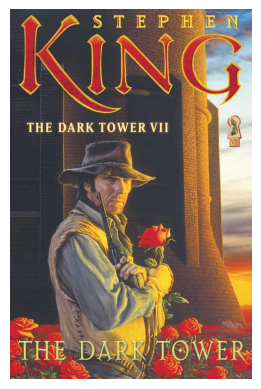

In [2]:
plt.imshow(img, cmap = 'gray')
plt.axis('off');

3. Separe os canais R (vermelho), G (verde) e B (azul) da imagem. Dica: use o método ``split`` da biblioteca.

In [3]:
r, g, b = Image.Image.split(img)

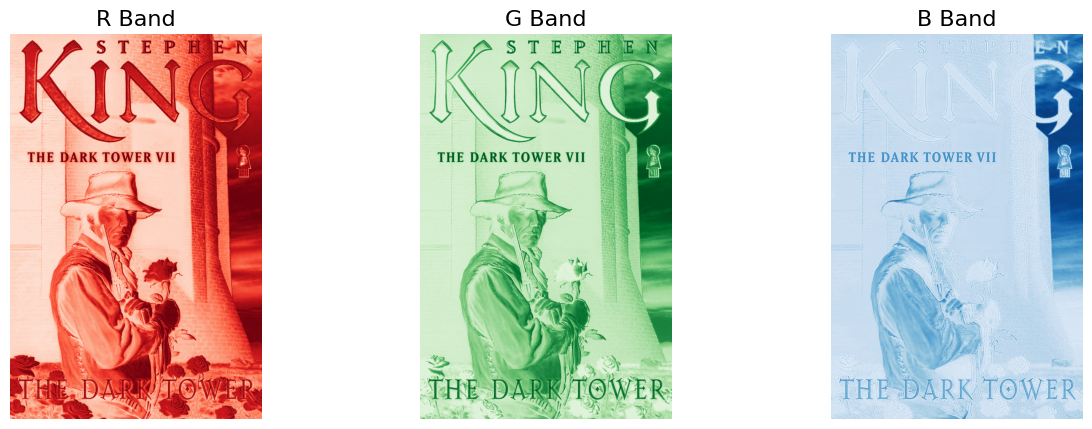

In [4]:
plt.subplots(1, 3, figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(r, cmap = 'Reds')
plt.title('R Band', size = 16)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(g, cmap = 'Greens')
plt.title('G Band', size = 16)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(b, cmap = 'Blues')
plt.title('B Band', size = 16)
plt.axis('off');

4. Aplique a técnica de compressão com perda baseada em SVD (que vimos na aula de SVD), mas para cada um dos canais individualmente. Para cada canal, faça um gráfico dos valores singulares para justificar o $k$ adequado. Do mais, faça gráficos para mostrar cada canal antes e após a compressão.

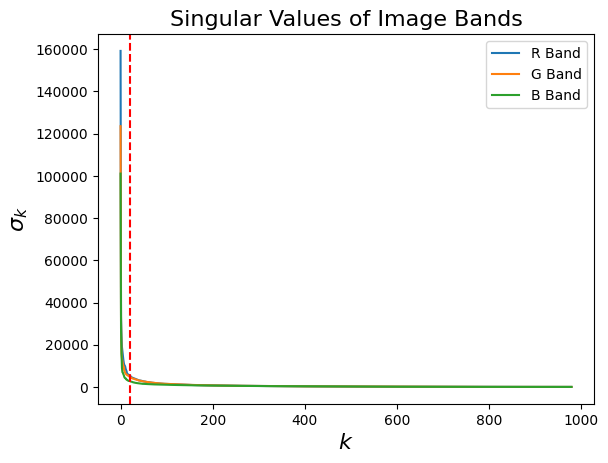

In [5]:
## R Band SVD
u, s, vt = np.linalg.svd(np.array(r), full_matrices = False)
plt.plot(s)

## G Band SVD
u, s, vt = np.linalg.svd(np.array(g), full_matrices = False)
plt.plot(s)

## B Band SVD
u, s, vt = np.linalg.svd(np.array(b), full_matrices = False)
plt.plot(s)

plt.axvline(x=20, color='r', linestyle='--', label='Vertical Line')

plt.xlabel('$k$', size = 16)
plt.ylabel(r'$\sigma_k$', size = 16)
plt.title('Singular Values of Image Bands', size = 16);
plt.legend(['R Band', 'G Band', 'B Band']);

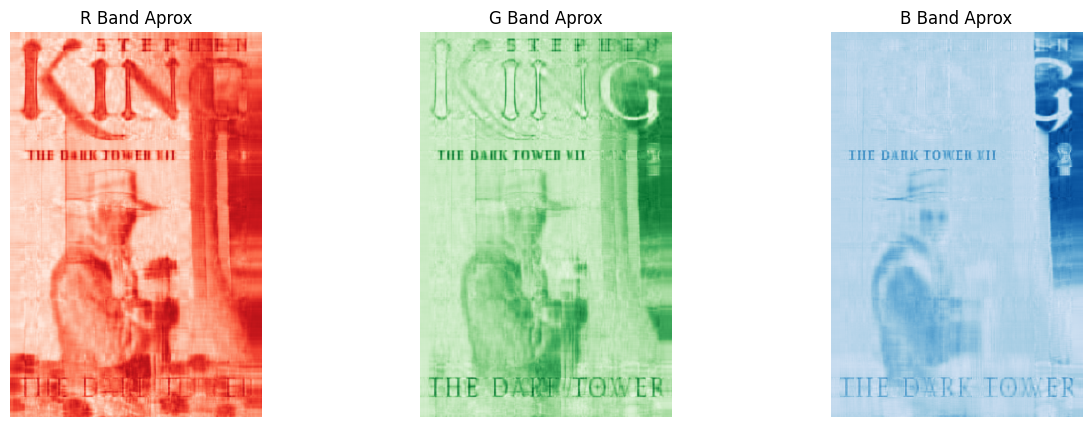

In [6]:
# Choosing rank k = 20
k = 20

## R Band Approximation
u, s, vt = np.linalg.svd(r, full_matrices = False)
s[k:] = 0
rband_aprox = u @ np.diag(s) @ vt

plt.subplots(1, 3, figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rband_aprox,cmap='Reds')
plt.title('R Band Aprox', size = 12)
plt.axis('off');

## G Band Approximation
u, s, vt = np.linalg.svd(g, full_matrices = False)
s[k:] = 0
gband_aprox = u @ np.diag(s) @ vt

plt.subplot(1, 3, 2)
plt.imshow(gband_aprox,cmap='Greens')
plt.title('G Band Aprox', size = 12)
plt.axis('off');

## B Band Approximation
u, s, vt = np.linalg.svd(b, full_matrices = False)
s[k:] = 0
bband_aprox = u @ np.diag(s) @ vt

plt.subplot(1, 3, 3)
plt.imshow(bband_aprox,cmap='Blues')
plt.title('B Band Aprox', size = 12)
plt.axis('off');

5. Utilizando o método ``merge`` da biblioteca PIL, junte os resultados das compressões para cada canal (ou seja, após a compressão) para formar uma imagem colorida e comprimida. Apresente a imagem resultante.

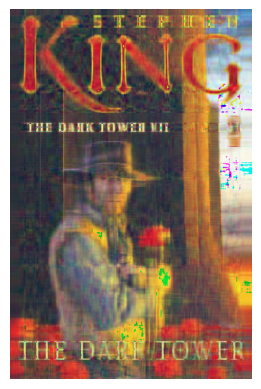

In [7]:
# NumPy Arrays to PIL Images
rband_aprox_img = Image.fromarray(np.uint8(rband_aprox))
gband_aprox_img = Image.fromarray(np.uint8(gband_aprox))
bband_aprox_img = Image.fromarray(np.uint8(bband_aprox))

# Juntar os canais
img_reconstructed = Image.merge('RGB', (rband_aprox_img, gband_aprox_img, bband_aprox_img))
plt.imshow(img_reconstructed)
plt.axis('off');

6. Varie os valores de $k$ do passo (4). Em cada caso, apresente a imagem colorida resultante, referente ao passo (5).

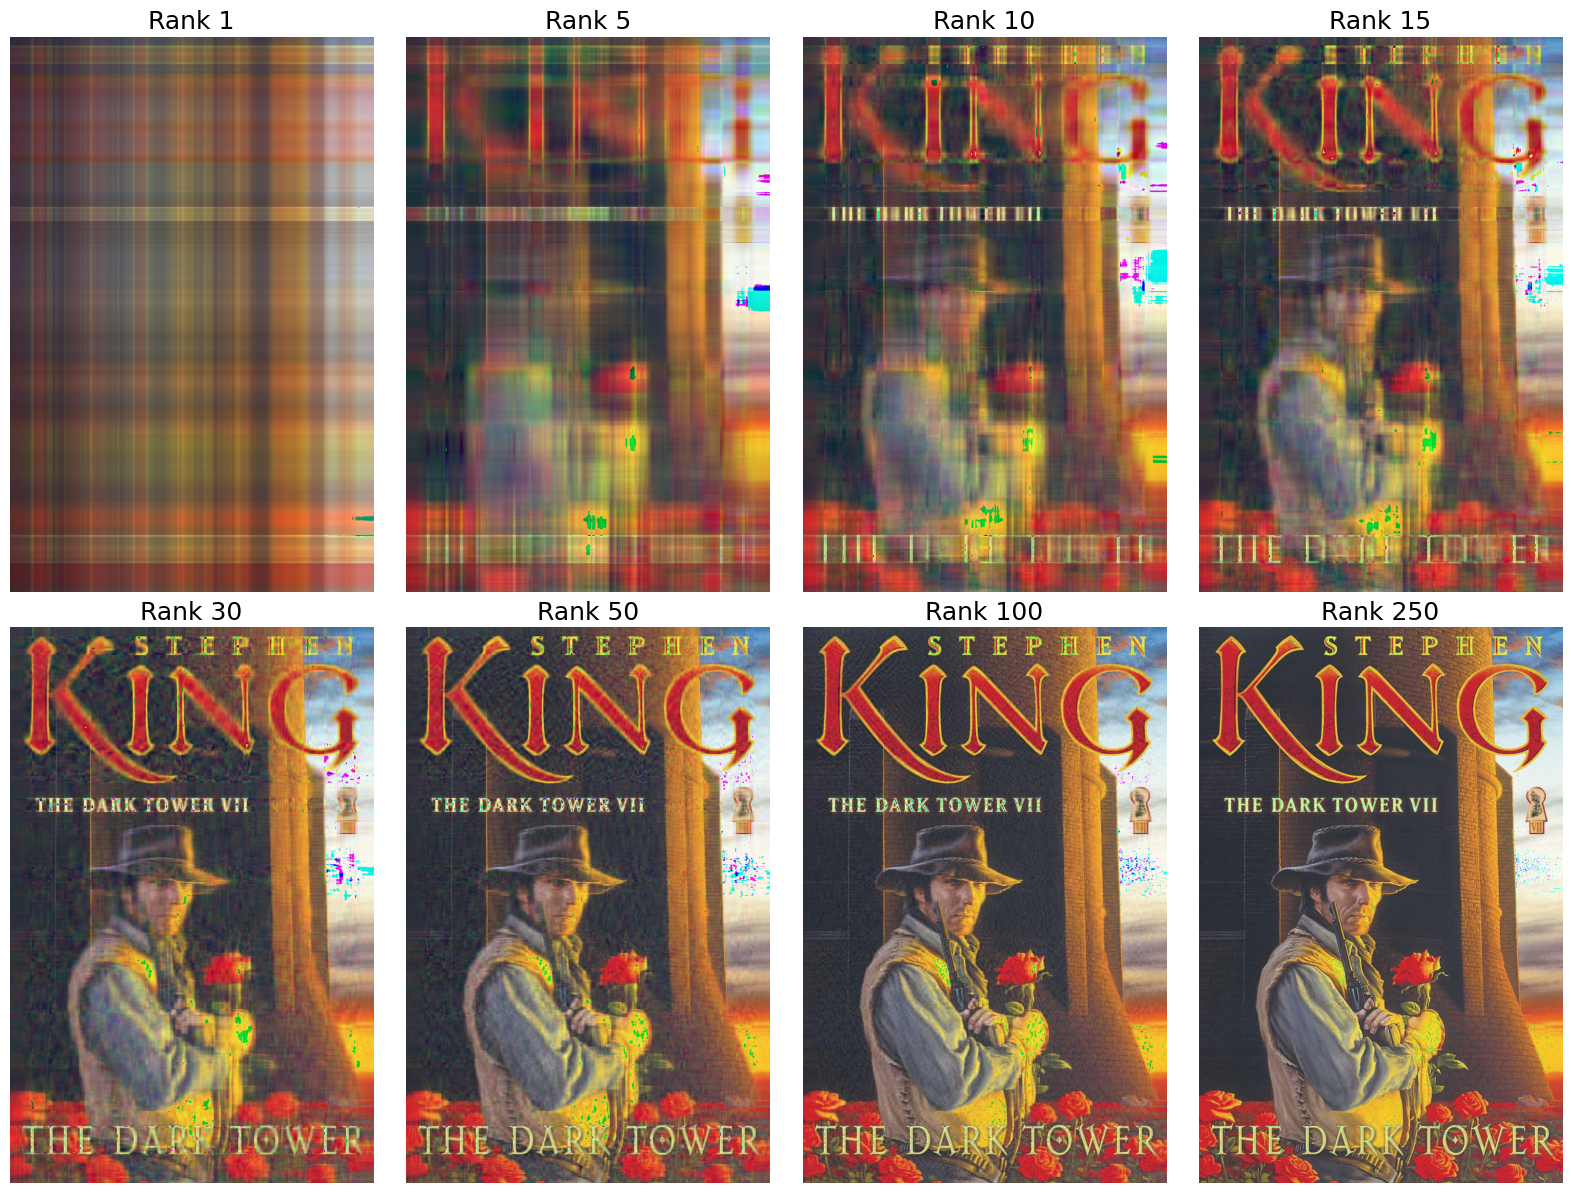

In [8]:
rank_values = [1, 5, 10, 15, 30, 50, 100, 250]

fig, axes = plt.subplots(2, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, k in enumerate(rank_values):
    # R Band Approximation
    u, s, vt = np.linalg.svd(r, full_matrices=False)
    s[k:] = 0
    rband_aprox = u @ np.diag(s) @ vt

    # G Band Approximation
    u, s, vt = np.linalg.svd(g, full_matrices=False)
    s[k:] = 0
    gband_aprox = u @ np.diag(s) @ vt

    # B Band Approximation
    u, s, vt = np.linalg.svd(b, full_matrices=False)
    s[k:] = 0
    bband_aprox = u @ np.diag(s) @ vt

    # NumPy Arrays to PIL Images
    rband_aprox_img = Image.fromarray(np.uint8(rband_aprox))
    gband_aprox_img = Image.fromarray(np.uint8(gband_aprox))
    bband_aprox_img = Image.fromarray(np.uint8(bband_aprox))

    # Juntar os canais
    img_reconstructed = Image.merge('RGB', (rband_aprox_img, gband_aprox_img, bband_aprox_img))
    
    # Plotar no subplot
    axes[idx].imshow(img_reconstructed)
    axes[idx].set_title(f'Rank {k}', size=18)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

7. No geral, é possível manter uma quantidade razoável da informação da imagem colorida economizando espaço de armazenamento de forma significativa? Justifique brevemente.

R: Sim, é possível. Utilizando um rank K mais baixo, a partir de 20, já é possível perceber informações relevantes da imagem como textos e alguns detalhes logo fica evidente que é possível manter informação reduzindo o tamanho da imagem.

## Questão 2 - Comparando PCA com MDS e TSNE

O objetivo dessa questão é apresentar e aplicar outras duas técnicas de redução de dimensionalidade e visualização de dados muito populares. Além disso, vamos comparar o resultado delas com PCA.

### PCA

1. Leia o conjunto de dados ``wine`` (já utilizado na aula de PCA). Além disso, aplique transformações e etapas de pré-processamento, como discutido em sala de aula, caso necessário.

In [9]:
from sklearn.datasets import load_wine

wine = load_wine(return_X_y = False, as_frame = True)
X = wine.data
y = wine.target.values
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [10]:
from sklearn import preprocessing
import pandas as pd

scaler = preprocessing.StandardScaler(with_mean = True, with_std = True)
scaler.fit(X)

X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, index = X.index, columns = X.columns)
X_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


2. Aplique PCA para reduzir o conjunto de dados para duas dimensões.

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca_2pc = pca.fit_transform(X_scaled)
print(f"Shape after PCA: {X_pca_2pc.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Shape after PCA: (178, 2)
Explained variance ratio: [0.36198848 0.1920749 ]


3. Utilize os dados reduzidos para visualizar o conjunto de dados no espaço 2D. Do mais, faça com que cada ponto no plano seja colorido/estilizado de acordo com a classe real que o objeto pertence (i.e., tipo de vinho -- esse dado é disponibilizado no conjunto de dados).

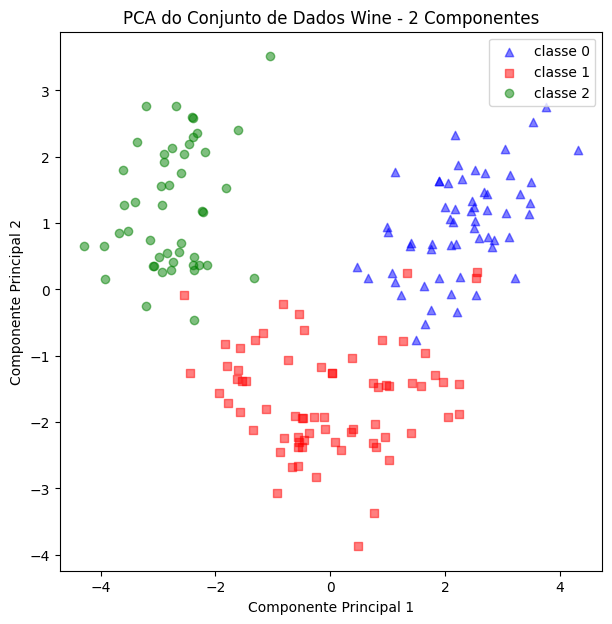

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  plt.scatter(X_pca_2pc[y == l, 0], X_pca_2pc[y == l, 1], color=c, label="classe %s" % l, alpha=0.5, marker=m)

plt.xlabel('Componente Principal 1');
plt.ylabel('Componente Principal 2');
plt.title('PCA do Conjunto de Dados Wine - 2 Componentes');
plt.legend(loc = 'best');

4. Repita os Passos (2) e (3) para 3 dimensões. Ou seja, use PCA para reduzir seu conjunto de dados para 3 dimensões e visualize os pontos (estilizados de acordo com a classe real) no espaço 3D.

In [13]:
pca = PCA(n_components = 3)
X_pca_3pc = pca.fit_transform(X_scaled)
print(f"Shape after PCA: {X_pca_3pc.shape}")

Shape after PCA: (178, 3)


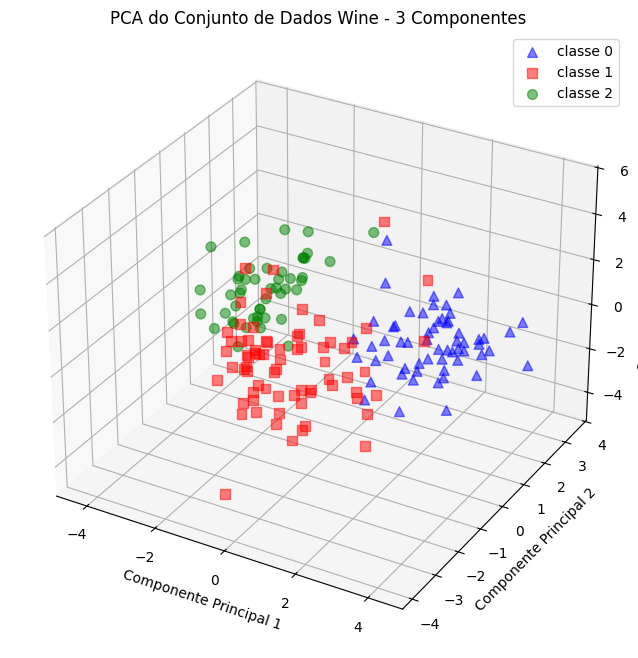

In [14]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  ax.scatter(X_pca_3pc[y == l, 0], X_pca_3pc[y == l, 1], X_pca_3pc[y == l, 2], 
             color=c, label="classe %s" % l, alpha=0.5, marker=m, s=50)

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('PCA do Conjunto de Dados Wine - 3 Componentes')
ax.legend(loc='best')
plt.show()

### MDS

Uma outra técnica para reduzir a dimensionalidade de um conjunto de dados é *Multidimensional Scaling* -- MDS.

Antes de continuar essa questão, leia o material disponível [aqui](https://www.statisticshowto.com/multidimensional-scaling/) e [aqui](https://www.geeksforgeeks.org/data-analysis/what-is-multidimensional-scaling/) e assista esse [vídeo](https://www.youtube.com/watch?v=GEn-_dAyYME).







Utilizando a implementação da biblioteca [``scikit-learn``](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html) de MDS, repita os Passos (1), (2), (3) e (4), realizados para PCA, acima.

Após isso, interprete e compare os resultados do MDS com aqueles obtidos com PCA.

Observe que o algoritmo do MDS possui uma componente aleatorizada. Repita seus experimentos algumas vezes sem fixar a semente do gerador de números pseudoaleatórios. Os resultados são sempre similares? Justifique brevemente.

Shape after MDS: (178, 2)


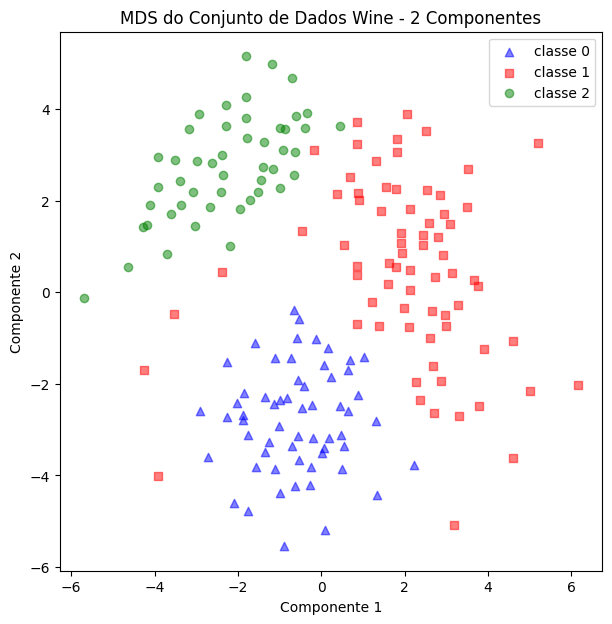

In [15]:
from sklearn.manifold import MDS

## Calculate MDS with 2 components
mds = MDS(n_components=2, n_init=1)
X_mds_2c = mds.fit_transform(X_scaled)
print(f"Shape after MDS: {X_mds_2c.shape}")


## Plot MDS with 2 components
plt.figure(figsize=(7, 7))
for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  plt.scatter(X_mds_2c[y == l, 0], X_mds_2c[y == l, 1], color=c, label="classe %s" % l, alpha=0.5, marker=m)

plt.xlabel('Componente 1');
plt.ylabel('Componente 2');
plt.title('MDS do Conjunto de Dados Wine - 2 Componentes');
plt.legend(loc = 'best');

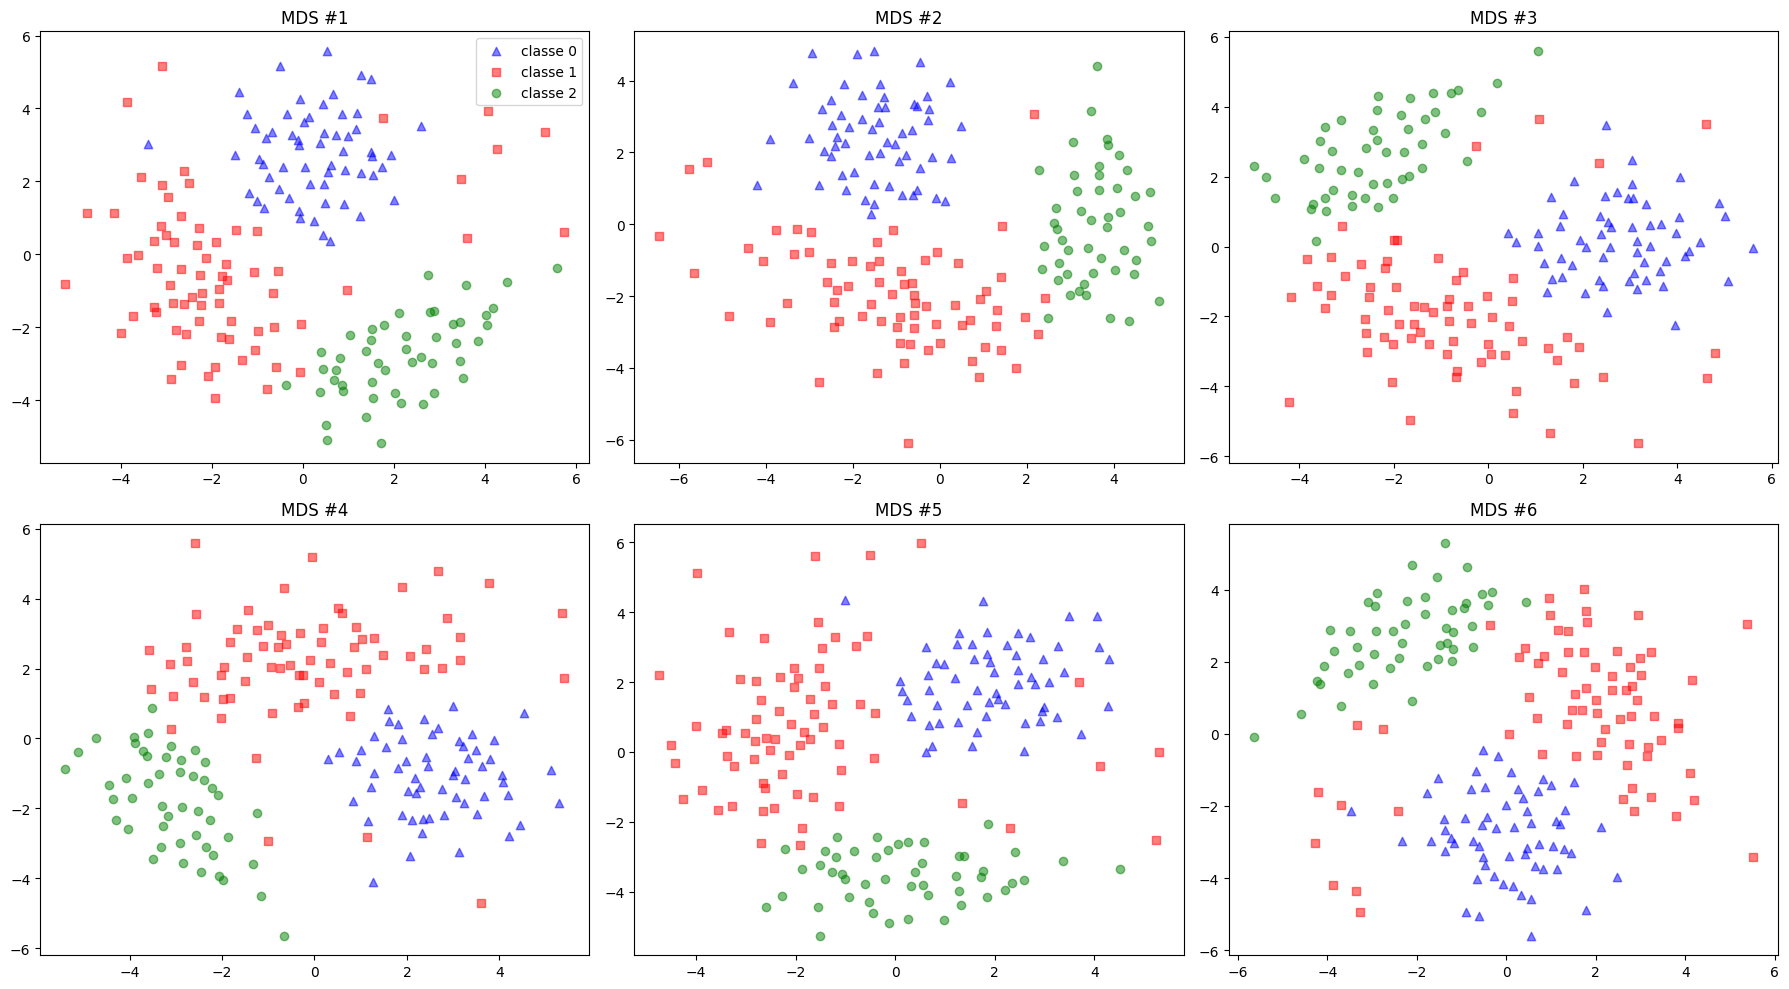

In [16]:
## Run MDS multiple times to observe variations due to random initialization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    mds = MDS(n_components=2, n_init=1, max_iter=300)
    X_mds_2c = mds.fit_transform(X_scaled)

    for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
        ax.scatter(X_mds_2c[y == l, 0], X_mds_2c[y == l, 1],
                   color=c, label=f"classe {l}", alpha=0.5, marker=m)

    ax.set_title(f'MDS #{i+1}')
    
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

Shape after MDS: (178, 3)


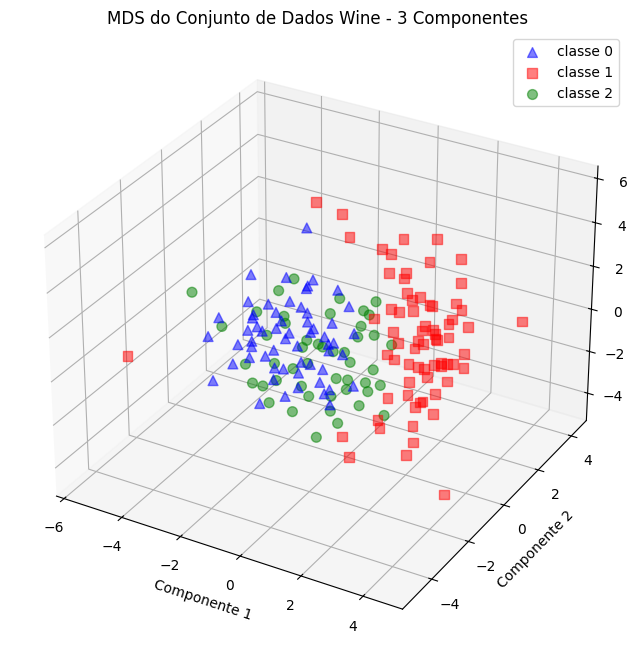

In [17]:
## Calculate MDS with 3 components

mds = MDS(n_components=3, n_init=1)
X_mds_3c = mds.fit_transform(X_scaled)
print(f"Shape after MDS: {X_mds_3c.shape}")


## Plot MDS with 3 components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  ax.scatter(X_mds_3c[y == l, 0], X_mds_3c[y == l, 1], X_mds_3c[y == l, 2], 
             color=c, label="classe %s" % l, alpha=0.5, marker=m, s=50)

ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_zlabel('Componente 3')
ax.set_title('MDS do Conjunto de Dados Wine - 3 Componentes')
ax.legend(loc='best')
plt.show()

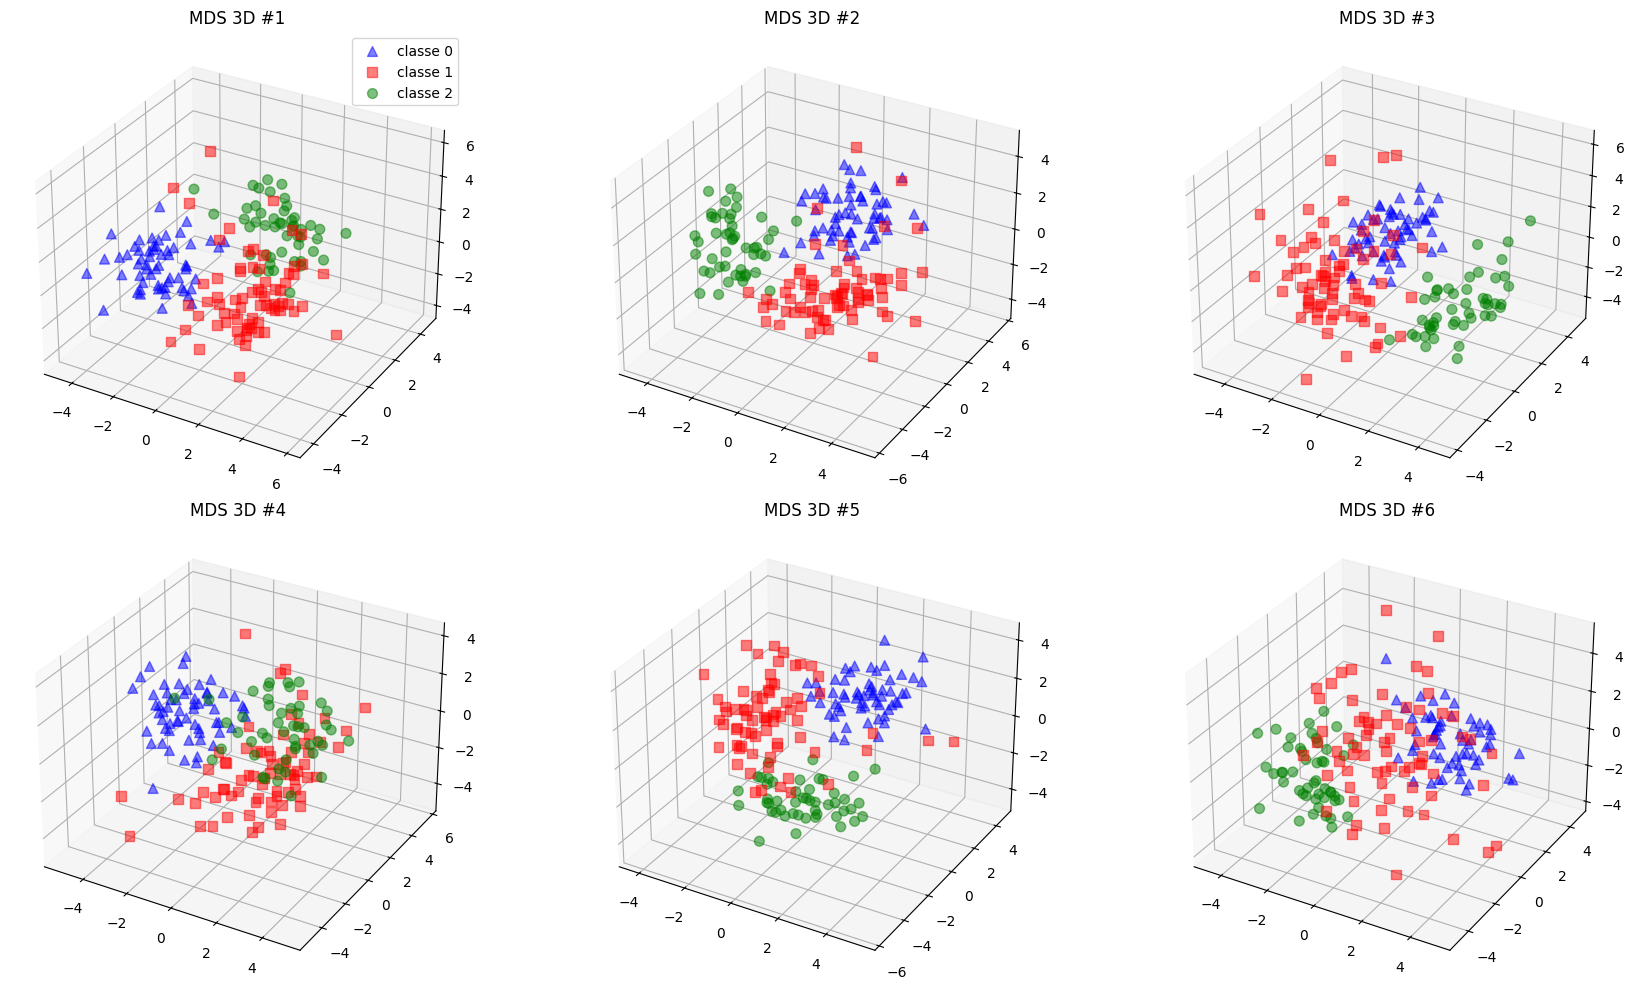

In [18]:
## Run MDS with 3 components multiple times to observe variations due to random initialization
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for i, ax in enumerate(axes):
    mds = MDS(n_components=3, n_init=1, max_iter=300)
    X_mds_3c = mds.fit_transform(X_scaled)

    for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
        ax.scatter(X_mds_3c[y == l, 0], X_mds_3c[y == l, 1], X_mds_3c[y == l, 2], 
                   color=c, label=f"classe {l}", alpha=0.5, marker=m, s=50)

    ax.set_title(f'MDS 3D #{i+1}')
    
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

**Escreva seus comentários aqui:**

Comparando o resultado do PCA com o resultado do MDS é possível perceber que em ambos os casos a separação entre as classes foi respeitada de forma clara sem muita sobreposição entre elas indicando que existem características que distinguenm bem os grupos, além disso o cluster da classe 0 parece muito mais coeso e menos disperso que os demais.

Comparando os resultados obtidos entre o PCA e o MDS eles são muito parecidos indicando e confirmando que o MDS utilizando a distância euclidiana é matematicamente equivalente ao PCA.

Os resultados do MDS variam porque a função de custo do MDS é não-convexa, e assim com a inicialização aleatória o algoritmo converge para diferentes mínimos locais em vez de uma solução global única. Além disso como o método preserva apenas distâncias relativas a projeção final é invariante a rotações e espelhamentos, podendo apresentar orientações visualmente diferentes a cada execução mas sem alterar a qualidade da representação.

### t-SNE

Uma outra técnica para reduzir a dimensionalidade de um conjunto de dados é *T-distributed Stochastic Neighbor Embedding* -- t-SNE.

Antes de continuar essa questão, leia o material disponível [aqui](https://www.datacamp.com/tutorial/introduction-t-sne) e assista esse [vídeo](https://www.youtube.com/watch?v=NEaUSP4YerM).







Utilizando a implementação da biblioteca [``scikit-learn``](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html#sklearn.manifold.TSNE) de t-SNE, repita os Passos (1), (2), (3) e (4), realizados para PCA, acima.

Após isso, interprete e compare os resultados do t-SNE com aqueles obtidos com PCA e MDS.

Novamente, observe que o algoritmo do t-SNE possui uma componente aleatorizada. Repita seus experimentos algumas vezes sem fixar a semente do gerador de números pseudoaleatórios. Os resultados são sempre similares? Justifique brevemente.

Shape after MDS: (178, 2)


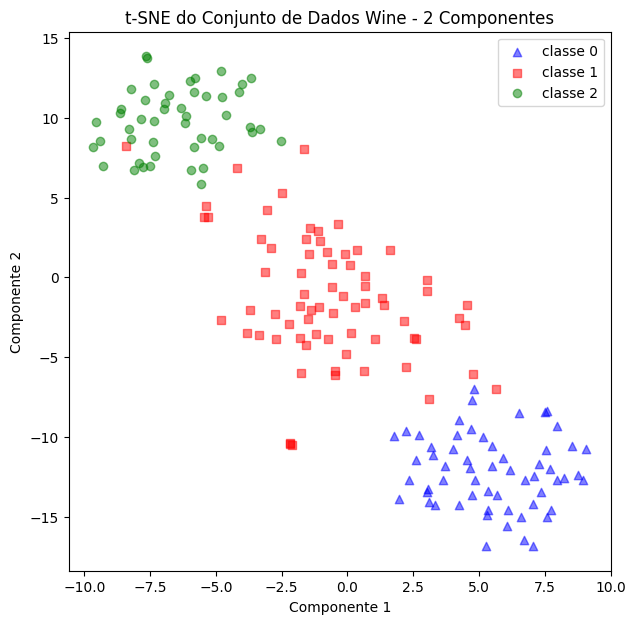

In [19]:
from sklearn.manifold import TSNE

## Calculate t-SNE with 2 components
tsne = TSNE(n_components=2)
X_tsne_2c = tsne.fit_transform(X_scaled)
print(f"Shape after MDS: {X_tsne_2c.shape}")


## Plot MDS with 2 components
plt.figure(figsize=(7, 7))
for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  plt.scatter(X_tsne_2c[y == l, 0], X_tsne_2c[y == l, 1], color=c, label="classe %s" % l, alpha=0.5, marker=m)

plt.xlabel('Componente 1');
plt.ylabel('Componente 2');
plt.title('t-SNE do Conjunto de Dados Wine - 2 Componentes');
plt.legend(loc = 'best');

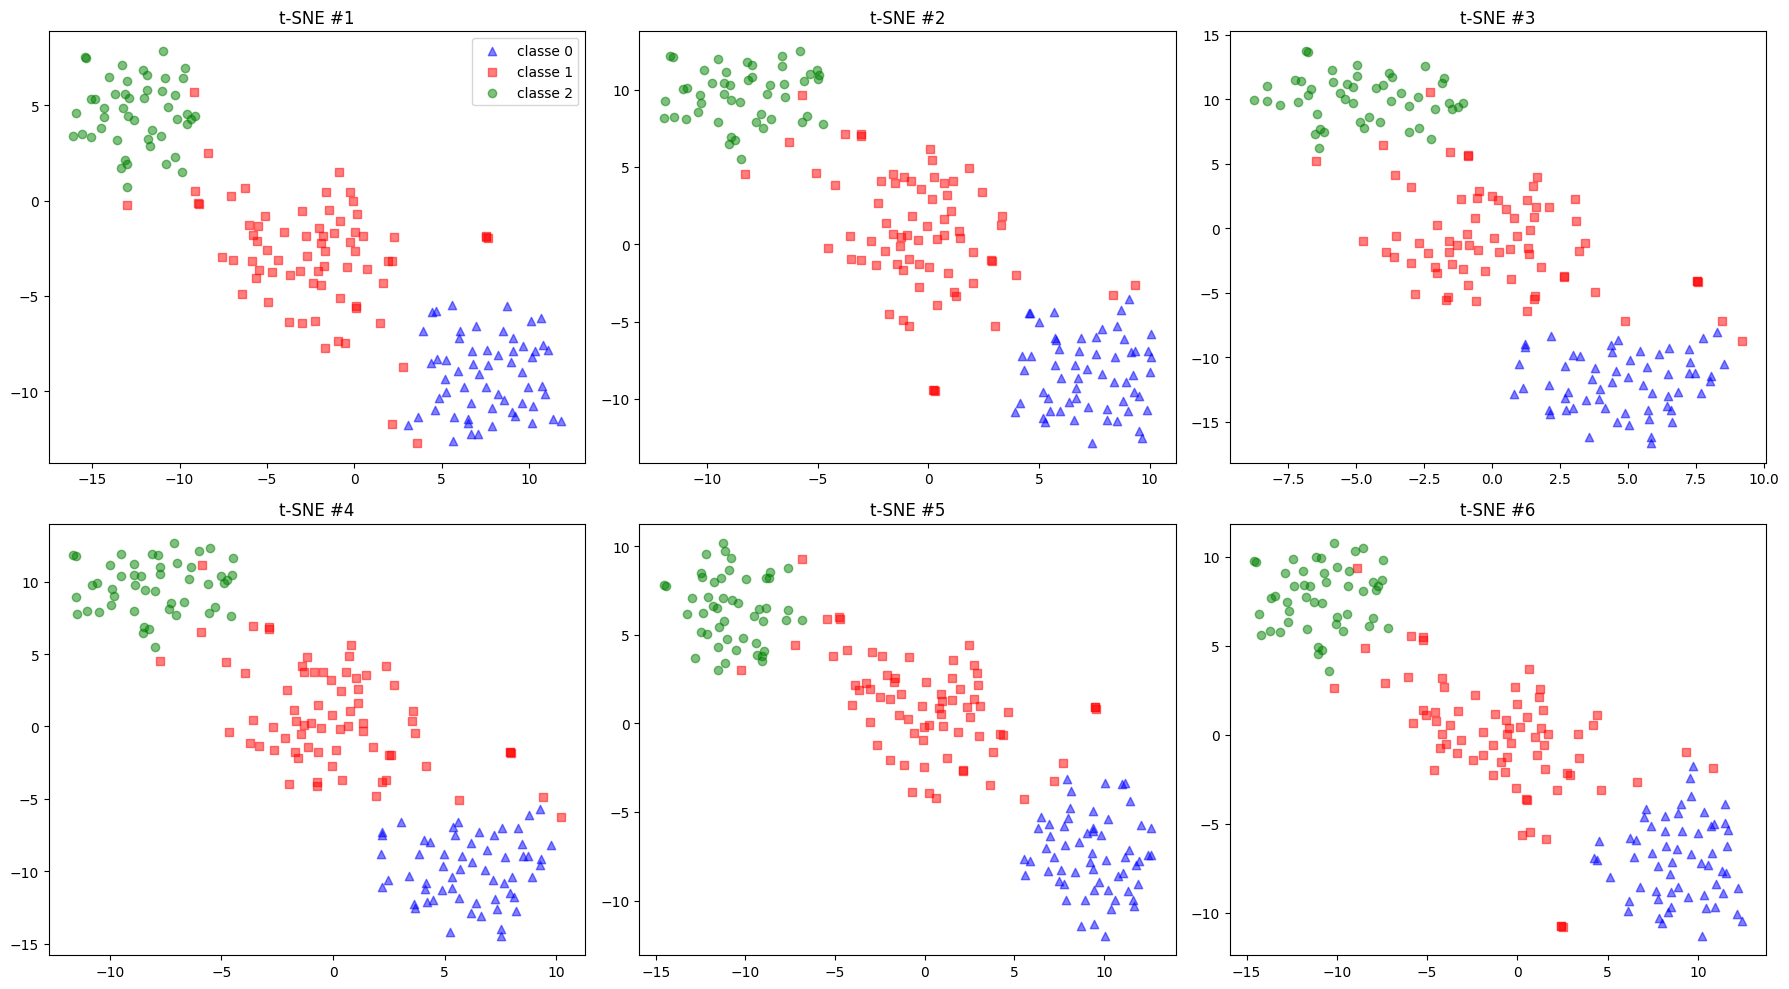

In [20]:
## Run t-SNE multiple times to observe variations due to random initialization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    tsne = TSNE(n_components=2)
    X_tsne_2c = tsne.fit_transform(X_scaled)

    for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
        ax.scatter(X_tsne_2c[y == l, 0], X_tsne_2c[y == l, 1],
                   color=c, label=f"classe {l}", alpha=0.5, marker=m)

    ax.set_title(f't-SNE #{i+1}')
    
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

Shape after MDS: (178, 3)


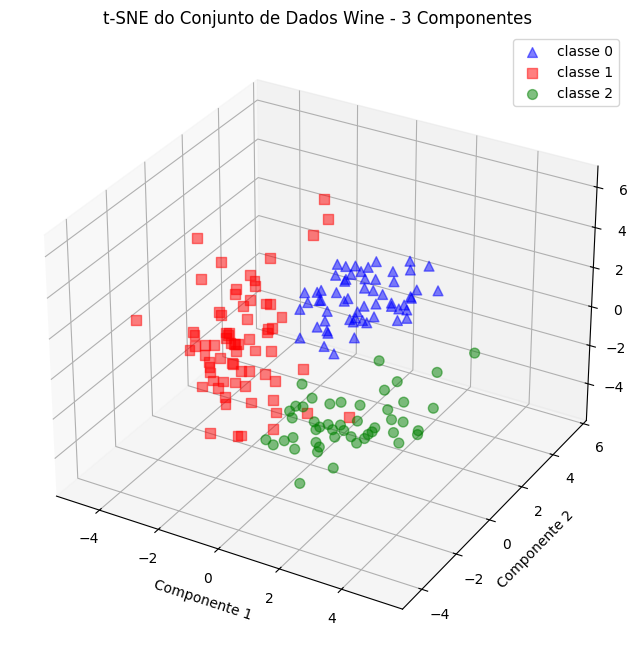

In [21]:
## Calculate MDS with 3 components
tsne = MDS(n_components=3, n_init=1)
X_tsne_3c = tsne.fit_transform(X_scaled)
print(f"Shape after MDS: {X_tsne_3c.shape}")


## Plot MDS with 3 components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  ax.scatter(X_tsne_3c[y == l, 0], X_tsne_3c[y == l, 1], X_tsne_3c[y == l, 2], 
             color=c, label="classe %s" % l, alpha=0.5, marker=m, s=50)

ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_zlabel('Componente 3')
ax.set_title('t-SNE do Conjunto de Dados Wine - 3 Componentes')
ax.legend(loc='best')
plt.show()

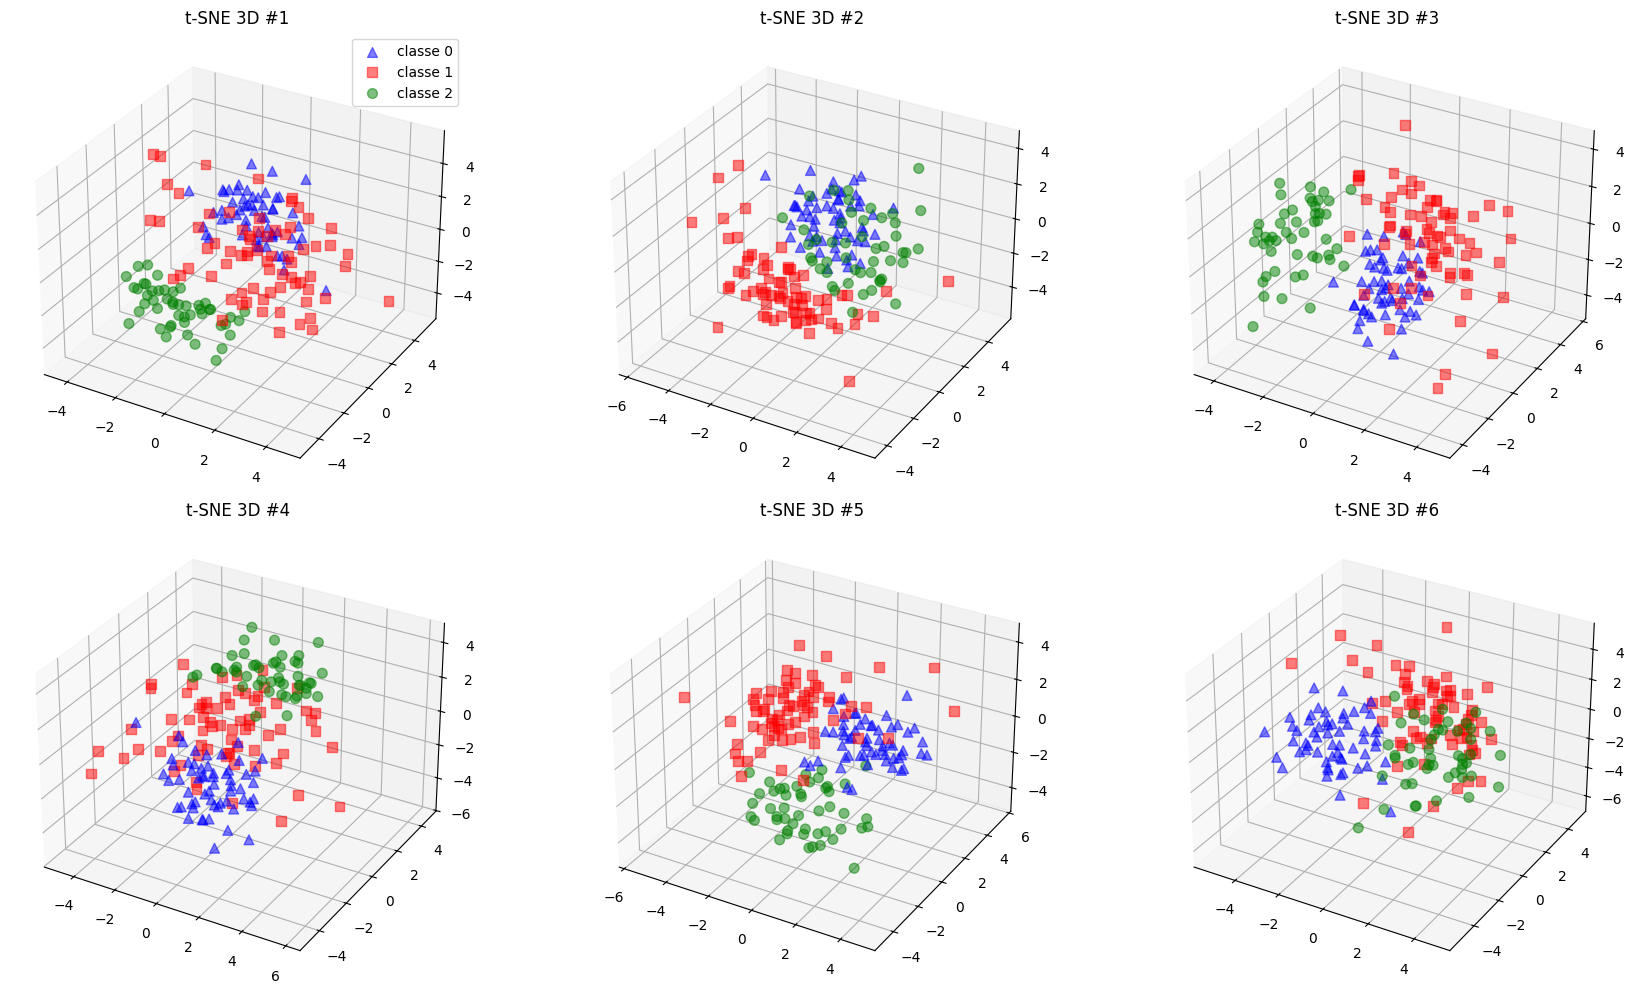

In [22]:
## Run t-SNE with 3 components multiple times to observe variations due to random initialization
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for i, ax in enumerate(axes):
    tsne = MDS(n_components=3, n_init=1)
    X_tsne_3c = tsne.fit_transform(X_scaled)

    for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
        ax.scatter(X_tsne_3c[y == l, 0], X_tsne_3c[y == l, 1], X_tsne_3c[y == l, 2], 
                   color=c, label=f"classe {l}", alpha=0.5, marker=m, s=50)

    ax.set_title(f't-SNE 3D #{i+1}')
    
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

**Escreva seus comentários aqui:**

Tanto o PCA quanto o MDS preservam a estrutura global e as distâncias reais dos dados. Se a Classe 1 está longe da Classe 2 no gráfico, elas são matematicamente distantes nos dados originais já no t-SNE ele preserva a estrutura local dos dados forçando pontos similares a ficarem muito próximos e pontos dissimilares a se afastarem, por isso a separação das classes no t-SNE é um pouco "artifical".

Assim como o MDS, o t-SNE minimiza uma função de custo não-convexa o que leva a diferentes mínimos locais. No entanto, a variação no t-SNE é mais drástica já que não apenas a rotação muda, mas a forma dos clusters e a posição relativa entre eles se alteraram bastante entre as execuções, porque o algoritmo não preserva a geometria global, focando apenas na vizinhança local.

## Questão 3 - Projeção Aleatória

Um outro paradigma para realizar redução de dimensionalidade é utilizando Projeções Aleatórias.

Leias as Seções 1, 2 e 3 do artigo *[Database-friendly random projections: Johnson-Lindenstrauss with binary coins](https://www.sciencedirect.com/science/article/pii/S0022000003000254)*.



1. Faça um resumo, de aproximadamente uma página A4, do material lido. Não deixe de incluir em seu resumo:
- A intuição de como o método funciona
- A problemática que o método se propõe a resolver
- Vantagens e desvantagens do método
- Uma breve interpretação do Lema 1.1 e Teorema 1.1 do artigo.

**Escreva seu resumo aqui:**

O problema central discutido no texto é a elevada complexidade computacional envolvida na redução de dimensionalidade em grandes conjuntos de dados. Métodos tradicionais baseados na incorporação de Johnson–Lindenstrauss (JL) projetam pontos em hiperplanos aleatórios com simetria esférica, o que exige multiplicar a matriz de dados por uma matriz densa composta por números reais. Essa operação é custosa, difícil de otimizar em bancos de dados e demanda um grande número de multiplicações de ponto flutuante.

A proposta do artigo simplifica significativamente a matriz de projeção sem comprometer a precisão na preservação das distâncias. A simetria esférica, segundo o autor, não é essencial — o fator determinante é a concentração de medida. A projeção pode ser interpretada como um estimador estatístico do comprimento do vetor original, em que cada coluna da matriz de projeção funciona como um estimador independente. Em vez de utilizar variáveis gaussianas, o autor demonstra que matrizes preenchidas com valores discretos simples, como $\{-1, 0, +1\}$, apresentam concentrações de probabilidade comparáveis às matrizes gaussianas. Na prática, isso transforma a projeção em operações de soma e subtração, eliminando a necessidade de multiplicações complexas.

O Lema 1.1 (Johnson–Lindenstrauss Clássico) estabelece que qualquer conjunto de $n$ pontos em alta dimensão pode ser projetado em um espaço de dimensão muito menor ($k$, logarítmico em $n$) preservando as distâncias entre pares de pontos dentro de um fator arbitrariamente pequeno $\epsilon$ arbitrariamente pequeno. Já o Teorema 1.1 (Contribuição de Achlioptas) demonstra que o resultado do Lema 1.1 pode ser alcançado usando uma matriz de projeção aleatória onde os elementos pertencem exclusivamente a distribuições discretas simples (como $\pm 1$ com probabilidade 0.5, ou $\pm 1$ e $0$). Garante a mesma precisão $\epsilon$ e probabilidade de sucesso que os métodos contínuos mais complexos.

Entre as vantagens da abordagem destacam-se:

 - Eficiência computacional: a projeção pode ser implementada com operações de agregação, evitando álgebra matricial densa.

 - Velocidade: devido à distribuição esparsa, apenas um terço dos atributos precisa ser processado para gerar cada nova coordenada, resultando em aceleração de até três vezes.

 - Simplicidade: elimina a necessidade de multiplicações e operações complexas associadas às matrizes gaussianas.

Como desvantagem, há a perda da simetria esférica presente nas distribuições gaussianas, o que torna a prova formal da concentração de medida mais trabalhosa, exigindo análise de vetores em “pior caso”. No entanto, o autor argumenta que essa perda não compromete o desempenho da técnica nem a qualidade da redução de dimensionalidade.

2. Escolha uma das formas de realizar a projeção descritas no Teorema 1.1 do artigo. Implemente o algoritmo para realizar a projeção escolhida (aqui você deve implementar sua própria função e não deve usar a implementação da ``scikit-learn``).

Após isso, repita os Passos (1), (2), (3) e (4) do item de PCA da Questão 2 utilizando o algoritmo de projeção aleatória implementado.

Após isso, interprete e compare os resultados da Projeção Aleatória com aqueles obtidos com as técnicas da Questão 2.

Novamente, observe que o algoritmo de Projeção Aleatória, como o próprio nome sugere, possui uma componente aleatorizada. Repita seus experimentos algumas vezes sem fixar a semente do gerador de números pseudoaleatórios. Os resultados são sempre similares? Justifique brevemente.

Com base no artigo lido e nos resultados observados, em que tipo de situação é provável que as vantagens desse método superem suas desvantagens?

In [23]:
def achlioptas_projection(X, k):
    n, d = X.shape
        
    choices = [-1, 0, 1]
    probs = [1/6, 2/3, 1/6]
    
    R = np.random.choice(choices, size=(d, k), p=probs)
    scaling_factor = np.sqrt(3) / np.sqrt(k)
    
    E = np.dot(X, R) * scaling_factor
    
    return E

Shape after random projection: (178, 2)


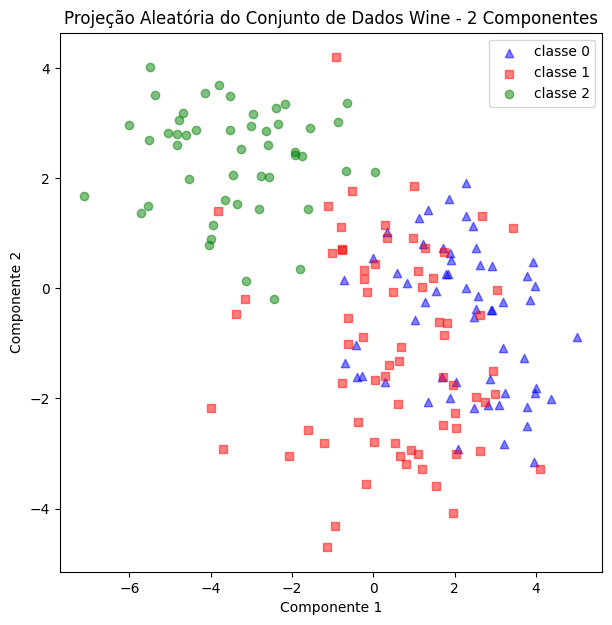

In [24]:
## Calculate random projection with 2 components
random_proj = achlioptas_projection(X_scaled, 2)
print(f"Shape after random projection: {random_proj.shape}")


## Plot random projection with 2 components
plt.figure(figsize=(7, 7))
for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  plt.scatter(random_proj[y == l, 0], random_proj[y == l, 1], color=c, label="classe %s" % l, alpha=0.5, marker=m)

plt.xlabel('Componente 1');
plt.ylabel('Componente 2');
plt.title('Projeção Aleatória do Conjunto de Dados Wine - 2 Componentes');
plt.legend(loc = 'best');

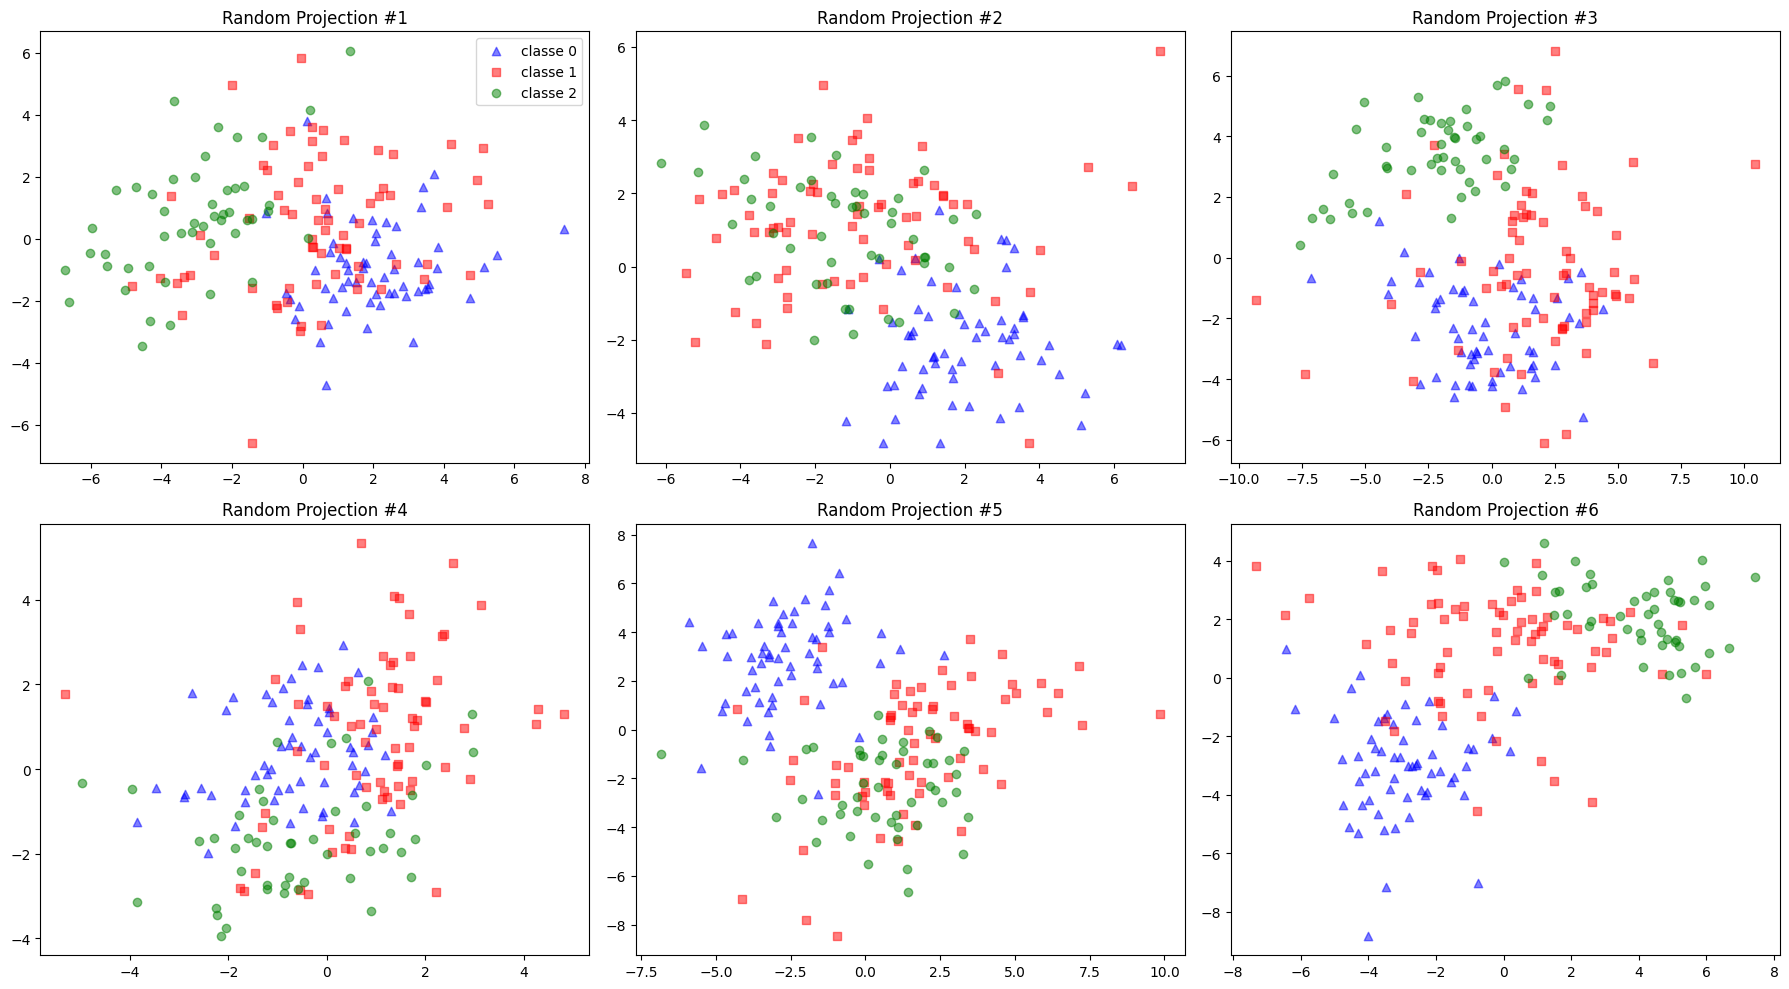

In [25]:
## Run random projection multiple times to observe variations due to random initialization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    random_proj = achlioptas_projection(X_scaled, 2)

    for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
        ax.scatter(random_proj[y == l, 0], random_proj[y == l, 1],
                   color=c, label=f"classe {l}", alpha=0.5, marker=m)

    ax.set_title(f'Random Projection #{i+1}')
    
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

Shape after random projection: (178, 3)


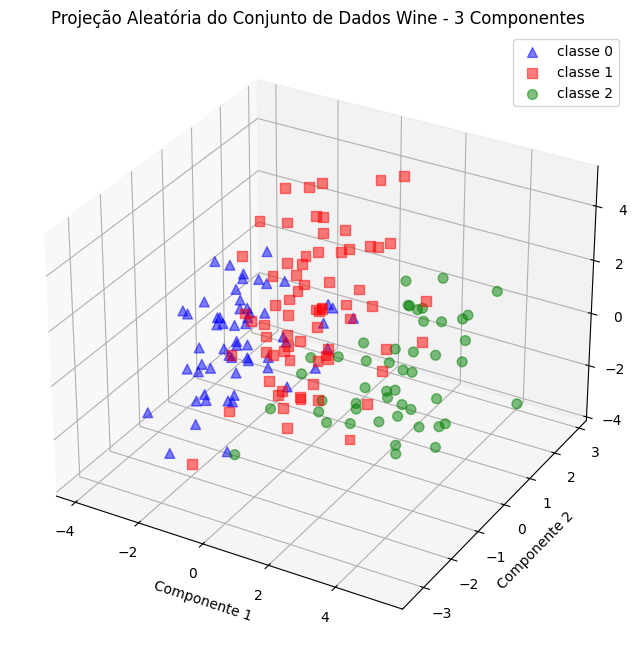

In [26]:
## Calculate random projection with 3 components
random_proj = achlioptas_projection(X_scaled, 3)
print(f"Shape after random projection: {random_proj.shape}")


## Plot random projection with 3 components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
  ax.scatter(random_proj[y == l, 0], random_proj[y == l, 1], random_proj[y == l, 2], 
             color=c, label="classe %s" % l, alpha=0.5, marker=m, s=50)

ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_zlabel('Componente 3')
ax.set_title('Projeção Aleatória do Conjunto de Dados Wine - 3 Componentes')
ax.legend(loc='best')
plt.show()

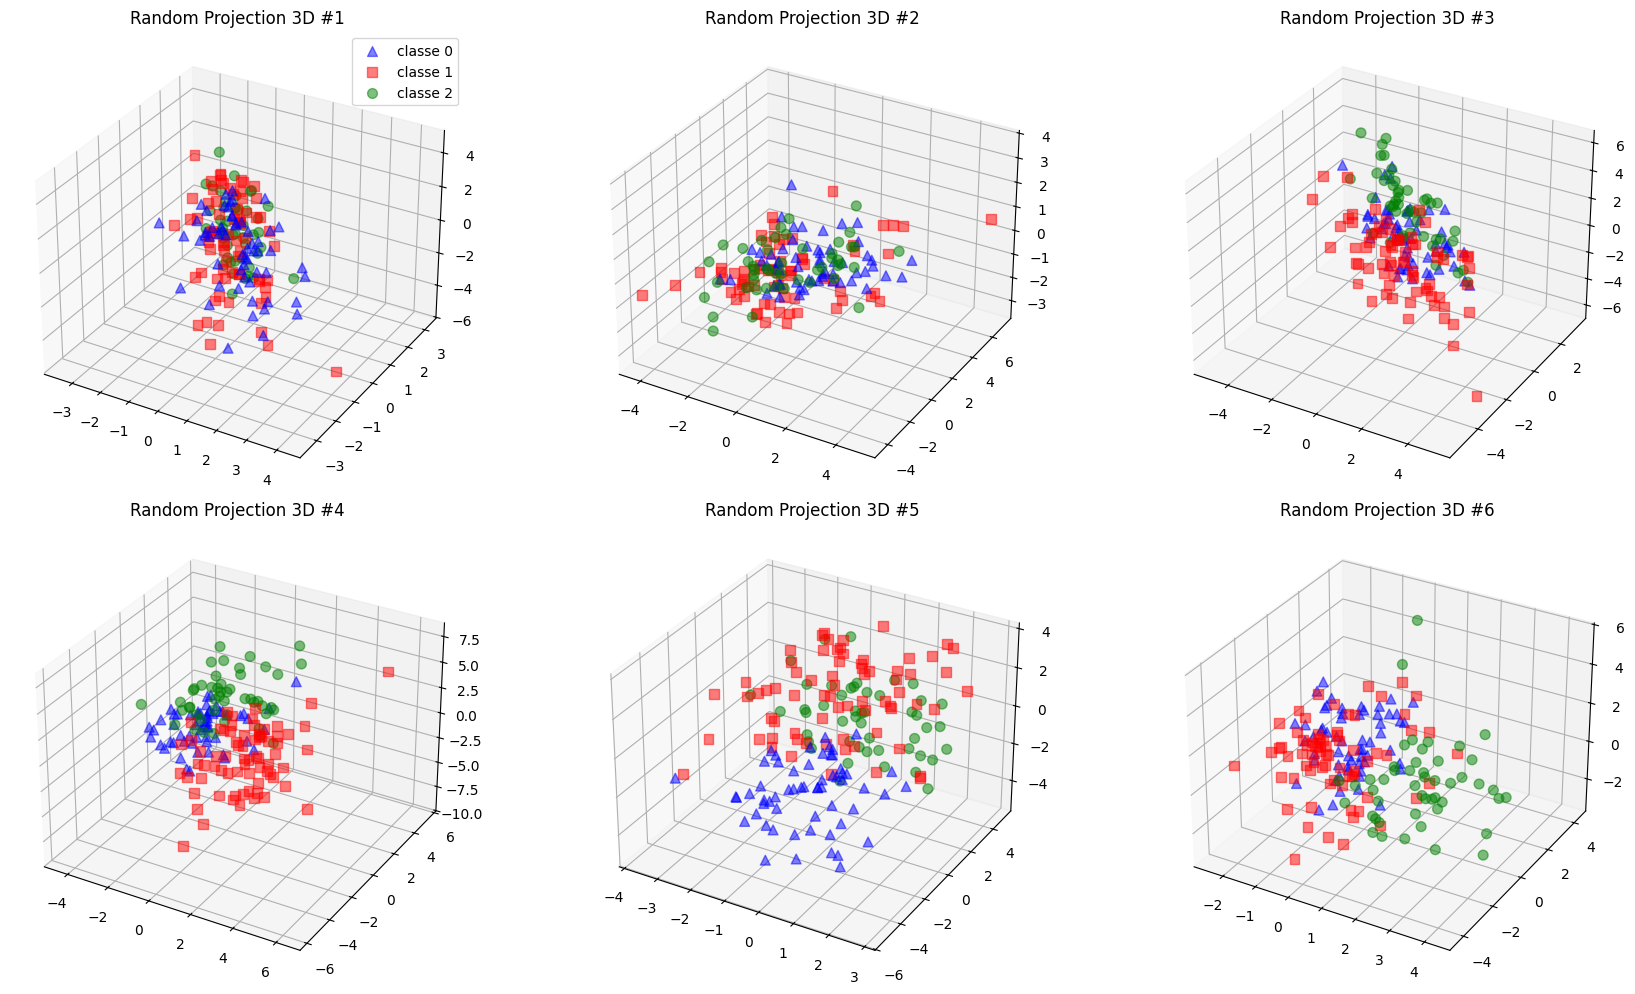

In [27]:
## Run random projection with 3 components multiple times to observe variations due to random initialization
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for i, ax in enumerate(axes):
    random_proj = achlioptas_projection(X_scaled, 3)

    for l, c, m in zip(range(0, 3), ("blue", "red", "green"), ("^", "s", "o")):
        ax.scatter(random_proj[y == l, 0], random_proj[y == l, 1], random_proj[y == l, 2], 
                   color=c, label=f"classe {l}", alpha=0.5, marker=m, s=50)

    ax.set_title(f'Random Projection 3D #{i+1}')
    
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

**Escreva seus comentários aqui:**

A Projeção Aleatória se diferencia de métodos como PCA, MDS e t-SNE por priorizar a eficiência computacional e a preservação global de distâncias euclidianas com menor custo computacional, diferentes dos outros métodos como por exemplo a busca por variância máxima ou visualização local não-linear que exigem cálculos complexos. Embora utilize uma componente estocástica, o método garante estabilidade estatística na estrutura topológica dos dados devido ao fenômeno da concentração de medida, sendo particularmente vantajoso em ambientes de banco de dados (SQL), processamento de streams e dados de altíssima dimensão, onde suas operações simples de agregação superam a inviabilidade computacional das abordagens tradicionais.